In [2]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
tf.keras.utils.set_random_seed(42)

In [4]:
(train_input,train_target),(test_input,test_target) = keras.datasets.fashion_mnist.load_data()
# print(train_input.shape)

train_scaled = train_input.reshape(-1,28,28,1) / 255.0

train_scaled,val_scaled,train_target,val_target = train_test_split(train_scaled, train_target,test_size=0.2,random_state=42)


In [5]:
model = keras.Sequential()

In [6]:
model.add(keras.layers.Conv2D(32,kernel_size=3,activation='relu',padding='same',input_shape=(28,28,1)))

e:\hanyong5_job\03python\02code\01test\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.add(keras.layers.MaxPooling2D(2))

In [8]:
model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu',padding='same'))
model.add(keras.layers.MaxPooling2D(2))

In [9]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100,activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10,activation='softmax'))


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.utils import plot_model
keras.utils.plot_model(model)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['acc']
    
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(train_scaled, train_target, 
                    epochs=20, 
                    callbacks=[checkpoint_cb,early_stopping_cb],
                    validation_data=(val_scaled,val_target)
                    )


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - acc: 0.8124 - loss: 0.5257 - val_acc: 0.8758 - val_loss: 0.3327
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - acc: 0.8751 - loss: 0.3491 - val_acc: 0.8948 - val_loss: 0.2832
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - acc: 0.8913 - loss: 0.3002 - val_acc: 0.9036 - val_loss: 0.2606
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - acc: 0.9030 - loss: 0.2675 - val_acc: 0.9111 - val_loss: 0.2467
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - acc: 0.9111 - loss: 0.2457 - val_acc: 0.9148 - val_loss: 0.2387
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - acc: 0.9176 - loss: 0.2228 - val_acc: 0.9151 - val_loss: 0.2369
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - acc: 0.9231 - loss: 0.2081 - val_acc: 0.9186 - val_loss: 0.2389
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - acc: 0.9293 - loss: 0.1899 - val_acc: 0.9193 - val_loss: 0.2336
Epoch 9/20
1500/1500 ━━━

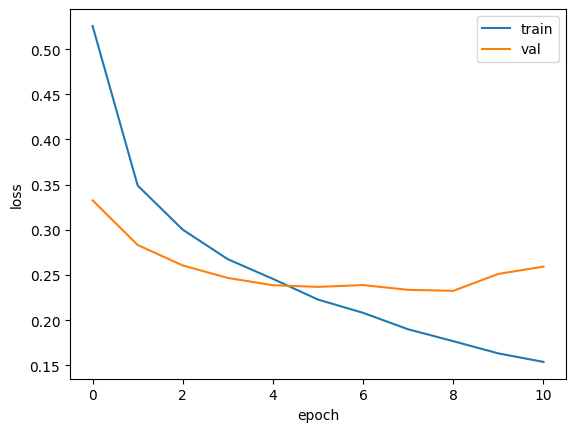

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

In [17]:
model.evaluate(val_scaled,val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9213 - loss: 0.2325


[0.23251082003116608, 0.9213333129882812]

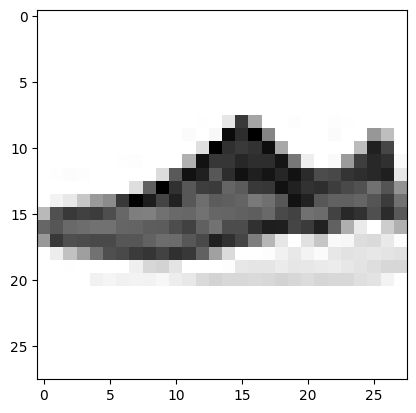

In [27]:
plt.imshow(val_scaled[2].reshape(28,28),cmap='gray_r')
plt.show()

In [28]:
preds = model.predict(val_scaled[2:3])
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[[6.8610368e-13 2.7787298e-18 2.3287964e-16 1.0299997e-18 1.8353844e-15
  5.0034565e-10 6.0152378e-16 9.9999988e-01 2.8035744e-15 1.6691922e-07]]


In [29]:
classes = ['티셔츠','바지','스웨터','드레스','코트', '샌달','셔츠','스티커즈','가방','앵클부츠']

In [30]:
import numpy as np
print(classes[np.argmax(preds)])

스티커즈
